## NYC 311 Service Requests Data Analysis

This project analyzes NYC 311 service request data to uncover patterns in public service demand across complaint types, agencies, boroughs, time periods, and geographic areas. Using Python, pandas, and visualization techniques, the notebook explores high-volume complaint categories, operational trends, and potential service hotspots to demonstrate how civic open data can support business analytics, resource planning, and data-driven decision-making.

---

#### Step 1: Download data via API

In [39]:
import pandas as pd # for data manipulation
from urllib.parse import urlencode # for building query parameters
import time # for adding delay between requests
from tqdm import tqdm # for showing progress bar
import geopandas as gpd # for geospatial data manipulation
import matplotlib.pyplot as plt # for plotting
import calendar # for month names
from sklearn.neighbors import BallTree
import numpy as np

In [40]:
# Constants
BASE_URL = "https://data.cityofnewyork.us/resource/erm2-nwe9.json"

LIMIT = 50000
YEAR = 2024

# Columns to select from the API
SELECT_COLUMNS = (
    "unique_key,created_date,closed_date,agency,complaint_type,"
    "descriptor,incident_zip,borough,latitude,longitude,status"
)

def get_total_rows(year):
    """Get the total number of rows for a given year to set up the progress bar.

    Args:
        year (int): The year for which to count the rows.
    Returns:
        int: The total number of rows for the specified year.
    """

    # Use the $select=count(*) to get the total number of rows for the specified year
    params = {
        "$select": "count(*)",
        "$where": (
            f"created_date between '{year}-01-01T00:00:00' "
            f"and '{year}-12-31T23:59:59'"
        )
    }

    # Build the URL with query parameters and make the request
    url = f"{BASE_URL}?{urlencode(params)}"
    result = pd.read_json(url)

    return int(result.iloc[0, 0])


def download_311_year(year):
    """Download 311 data for a specific year in chunks and concatenate them into a single DataFrame.

    Args:
        year (int): The year for which to download the data.
    Returns:
        pd.DataFrame: The concatenated DataFrame containing the downloaded data.
    """

    # Get the total number of rows for the specified year to set up the progress bar
    total_rows = get_total_rows(year)

    offset = 0
    chunks = []

    progress_bar = tqdm(total=total_rows, desc=f"Downloading NYC 311 data for {year}")

    # Loop to download data in chunks until there are no more rows to download
    while True:
        params = {
            "$limit": LIMIT,
            "$offset": offset,
            "$select": SELECT_COLUMNS,
            "$where": (
                f"created_date between '{year}-01-01T00:00:00' "
                f"and '{year}-12-31T23:59:59'"
            ),
            "$order": "created_date"
        }

        url = f"{BASE_URL}?{urlencode(params)}"
        chunk = pd.read_json(url)

        # If the chunk is empty, we have downloaded all the data for the year
        if chunk.empty:
            break

        chunks.append(chunk)

        rows_downloaded = len(chunk)
        offset += rows_downloaded
        progress_bar.update(rows_downloaded)

        # Add a short delay to avoid overwhelming the API
        time.sleep(0.5)

    progress_bar.close()

    # Concatenate all the chunks into a single DataFrame
    return pd.concat(chunks, ignore_index=True)

# Download the 311 data for the specified year
df = download_311_year(YEAR)

print(f"Finished downloading {len(df)} rows.")

Finished downloading 3456770 rows.


#### Step 2: The dataset is very large, so we will pull a stratified sample from the full dataset

In [41]:
def create_stratified_sample(df, sample_size):
    """
    Creates a representative sample based on borough and complaint type.

    Args:
        df (pd.DataFrame): The input DataFrame containing the 311 data.
        sample_size (int): The desired size of the stratified sample.
    Returns:
        pd.DataFrame: A stratified sample of the input DataFrame.
    """

    # Create a copy of the DataFrame to avoid modifying the original
    df = df.copy()

    # Fill missing values in 'borough' and 'complaint_type' with 'Unknown' to ensure they are included in the stratification
    df["borough"] = df["borough"].fillna("Unknown")
    df["complaint_type"] = df["complaint_type"].fillna("Unknown")

    # Create a new column that combines 'borough' and 'complaint_type' to define the strata
    df["stratum"] = df["borough"] + " | " + df["complaint_type"]

    # Sample from each stratum proportionally to its size in the original DataFrame
    stratified_df = (
        df.groupby("stratum", group_keys=False)
          .apply(lambda x: x.sample(
              n=max(1, round(len(x) / len(df) * sample_size)),
              random_state=42
          ))
    )

    # Rounding can make the sample slightly larger than requested
    sample_df = stratified_df.sample(
        n=min(sample_size, len(stratified_df)),
        random_state=42
    )

    return sample_df

In [42]:
# Create a stratified sample of the data
sample_df = create_stratified_sample(df, 100000)

print(f"Created stratified sample with {len(sample_df)} rows.")

# Save the sample to a CSV file
sample_df.to_csv(f"nyc_311_{YEAR}_stratified_sample.csv", index=False)

print(f"Saved sample to nyc_311_{YEAR}_stratified_sample.csv")

Created stratified sample with 100000 rows.
Saved sample to nyc_311_2024_stratified_sample.csv


---
### Load data from CSV
That way we don't need to keep downloading it repeatedly.

In [71]:
# load data from csv
sample_df = pd.read_csv("nyc_311_2024_stratified_sample.csv")

---
### Compare data distributions

In [44]:
def compare_distribution(full_df, sample_df, column):
    """
    Compare the distribution of a categorical column between the full dataset and the sample.
    Args:
        full_df (pd.DataFrame): The full dataset.
        sample_df (pd.DataFrame): The sampled dataset.
        column (str): The name of the categorical column to compare.
    Returns:
        pd.DataFrame: A DataFrame showing the distribution in both datasets and the difference.
    """
    
    full_dist = full_df[column].value_counts(normalize=True).rename("full")
    sample_dist = sample_df[column].value_counts(normalize=True).rename("sample")

    comparison = pd.concat([full_dist, sample_dist], axis=1).fillna(0)
    comparison["difference"] = comparison["sample"] - comparison["full"]

    return comparison.sort_values("full", ascending=False)


print(compare_distribution(df, sample_df, "borough"))
print(compare_distribution(df, sample_df, "agency"))
print(compare_distribution(df, sample_df, "complaint_type").head(20))

                   full   sample  difference
borough                                     
BROOKLYN       0.302326  0.30198   -0.000346
QUEENS         0.239261  0.23890   -0.000361
BRONX          0.213505  0.21353    0.000025
MANHATTAN      0.209084  0.20890   -0.000184
STATEN ISLAND  0.035061  0.03544    0.000379
Unspecified    0.000763  0.00125    0.000487
                full   sample    difference
agency                                     
NYPD    4.478371e-01  0.44714 -6.971428e-04
HPD     2.123158e-01  0.21200 -3.158324e-04
DSNY    8.856707e-02  0.08876  1.929273e-04
DOT     5.924808e-02  0.05961  3.619158e-04
DEP     5.544772e-02  0.05533 -1.177156e-04
DPR     4.003911e-02  0.04001 -2.911166e-05
DOB     2.974366e-02  0.03007  3.263376e-04
DOHMH   2.619989e-02  0.02657  3.701082e-04
DHS     1.504005e-02  0.01471 -3.300518e-04
TLC     1.093188e-02  0.01119  2.581185e-04
EDC     8.298498e-03  0.00827 -2.849831e-05
DCWP    5.778805e-03  0.00577 -8.805069e-06
DOE     5.065422e-04  0.

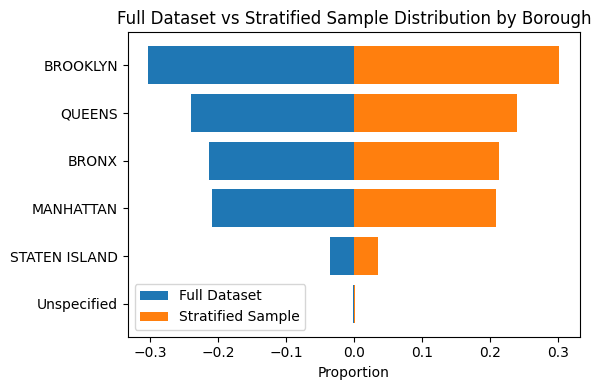

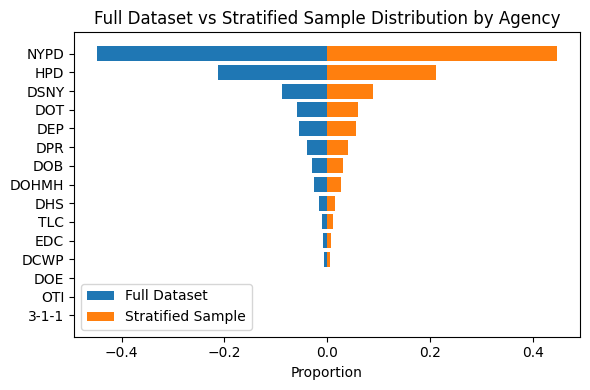

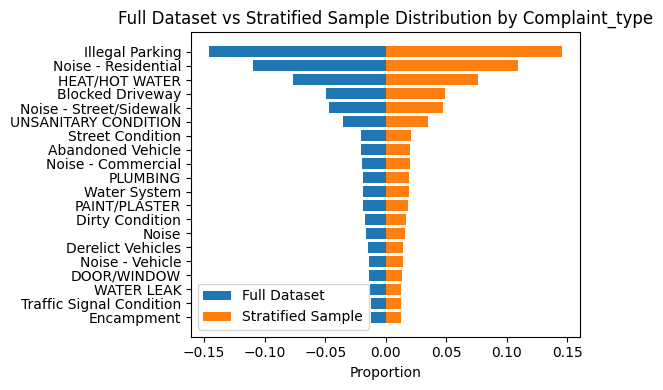

In [45]:
import matplotlib.pyplot as plt

for col in ["borough", "agency", "complaint_type"]:
    comparison = compare_distribution(df, sample_df, col).head(20).reset_index()
    comparison = comparison.rename(columns={"index": col})
    comparison = comparison.sort_values("full", ascending=True)

    plt.figure(figsize=(6, 4))
    plt.barh(comparison[col], -comparison["full"], label="Full Dataset")
    plt.barh(comparison[col], comparison["sample"], label="Stratified Sample")
    plt.xlabel("Proportion")
    plt.title(f"Full Dataset vs Stratified Sample Distribution by {col.capitalize()}")
    plt.legend()
    plt.tight_layout()
    plt.show()

---
### Step 3: Examine the data

In [46]:
sample_df.head()

,unique_key,created_date,closed_date,agency,complaint_type,descriptor,incident_zip,borough,latitude,longitude,status
0,61889094,2024-07-16T11:01:56.000,2024-09-17T00:00:00.000,DOB,Elevator,Elevator - Multiple Devices On Property,11372.0,QUEENS,40.751710,-73.881815,Closed
1,60368878,2024-02-20T15:09:07.000,2024-02-20T16:02:35.000,HPD,HEAT/HOT WATER,ENTIRE BUILDING,10457.0,BRONX,40.854439,-73.898423,Closed
2,60070802,2024-01-18T21:56:55.000,2024-01-19T20:52:29.000,HPD,HEAT/HOT WATER,APARTMENT ONLY,11221.0,BROOKLYN,40.687637,-73.938323,Closed
3,61824412,2024-07-16T00:13:56.000,2024-07-18T13:54:30.000,HPD,UNSANITARY CONDITION,MOLD,11421.0,QUEENS,40.691129,-73.847943,Closed
4,62558141,2024-09-24T11:13:08.000,2024-09-24T13:47:42.000,NYPD,Noise - Commercial,Loud Music/Party,10006.0,MANHATTAN,40.708351,-74.014323,Closed


In [47]:
# view data types and non-null counts in the sample
sample_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   unique_key      100000 non-null  int64  
 1   created_date    100000 non-null  str    
 2   closed_date     98108 non-null   str    
 3   agency          100000 non-null  str    
 4   complaint_type  100000 non-null  str    
 5   descriptor      96753 non-null   str    
 6   incident_zip    98949 non-null   float64
 7   borough         100000 non-null  str    
 8   latitude        98430 non-null   float64
 9   longitude       98430 non-null   float64
 10  status          100000 non-null  str    
dtypes: float64(3), int64(1), str(7)
memory usage: 8.4 MB


In [48]:
# get list of columns with null values in the sample
columns_with_nulls = sample_df.columns[sample_df.isnull().any()].tolist()
print("Columns with null values in the sample:")
print(columns_with_nulls)

Columns with null values in the sample:
['closed_date', 'descriptor', 'incident_zip', 'latitude', 'longitude']


In [49]:
# view count of unique values in each column of the sample
sample_df.nunique()

unique_key        100000
created_date       98993
closed_date        92223
agency                14
complaint_type       197
descriptor           752
incident_zip         220
borough                6
latitude           64055
longitude          64055
status                 7
dtype: int64

In [50]:
# Check for duplicates of unique_key in the sample
duplicate_keys = sample_df[sample_df.duplicated(subset="unique_key", keep=False)]
duplicate_keys.head()

,unique_key,created_date,closed_date,agency,complaint_type,descriptor,incident_zip,borough,latitude,longitude,status


In [51]:
# View categorical variable values and their counts in the sample
for col in ["borough", "agency", "complaint_type"]:
    print(f"Value counts for {col} in the sample:")
    print(sample_df[col].value_counts())
    print("\n")

Value counts for borough in the sample:
borough
BROOKLYN         30198
QUEENS           23890
BRONX            21353
MANHATTAN        20890
STATEN ISLAND     3544
Unspecified        125
Name: count, dtype: int64


Value counts for agency in the sample:
agency
NYPD     44714
HPD      21200
DSNY      8876
DOT       5961
DEP       5533
DPR       4001
DOB       3007
DOHMH     2657
DHS       1471
TLC       1119
EDC        827
DCWP       577
DOE         50
OTI          7
Name: count, dtype: int64


Value counts for complaint_type in the sample:
complaint_type
Illegal Parking               14598
Noise - Residential           10944
HEAT/HOT WATER                 7647
Blocked Driveway               4906
Noise - Street/Sidewalk        4702
                              ...  
Sustainability Enforcement        1
Building Marshals office          1
Stalled Sites                     1
SNW                               1
Tunnel Condition                  1
Name: count, Length: 197, dtype: int64




---
### Step 4: Cleaning -- Group Complaints and Standardize

In [72]:
# Load the complaint type crosswalk
crosswalk = pd.read_csv("complaint_type_mapping.csv")

# Clean text fields to prevent mismatches from extra spaces
sample_df["complaint_type"] = sample_df["complaint_type"].astype("string").str.strip()
crosswalk["complaint_type"] = crosswalk["complaint_type"].astype("string").str.strip()
crosswalk["category"] = crosswalk["category"].astype("string").str.strip()
crosswalk["complaint_type_clean"] = crosswalk["complaint_type_clean"].astype("string").str.strip()

# Merge the broad category onto the main dataframe
sample_df = sample_df.merge(
    crosswalk,
    how="left",
    left_on="complaint_type",
    right_on="complaint_type"
)

# Drop extra crosswalk column
sample_df = sample_df.drop(columns=["complaint_type"])

# Rename the clean complaint type column back to "complaint_type"
sample_df = sample_df.rename(columns={"complaint_type_clean": "complaint_type"})

# Check results
sample_df[["complaint_type", "category"]].head()

,complaint_type,category
0,Elevator,Housing and Building Maintenance
1,Heat/Hot Water,Housing and Building Maintenance
2,Heat/Hot Water,Housing and Building Maintenance
3,Unsanitary Condition,Sanitation and Waste
4,Noise - Commercial,Noise and Public Nuisance


#### Standardize Capitalization

In [73]:
# convert all values of borough to uppercase
sample_df["borough"] = sample_df["borough"].str.upper()
sample_df["borough"].value_counts()

borough
BROOKLYN         30198
QUEENS           23890
BRONX            21353
MANHATTAN        20890
STATEN ISLAND     3544
UNSPECIFIED        125
Name: count, dtype: int64

#### Deal with Missing Location Info

In [74]:
# Remove records without borough or geographic coordinates
before = len(sample_df)

sample_df = sample_df.dropna(subset=["borough", "latitude", "longitude"])

# Remove invalid borough labels
invalid_boroughs = ["UNSPECIFIED"]
sample_df = sample_df[~sample_df["borough"].isin(invalid_boroughs)]

after = len(sample_df)

print(f"Removed {before - after} records missing usable location data.")
print(f"Remaining records: {after}")

Removed 1599 records missing usable location data.
Remaining records: 98401


In [75]:
# Standardize ZIP code format
sample_df["incident_zip"] = (
    sample_df["incident_zip"]
    .astype("string")
    .str.extract(r"(\d{5})", expand=False)
)

def impute_zip_from_coordinates(df):
    """
    Impute missing ZIP codes using nearest ZIP centroid estimated from
    records that already have valid ZIP codes and coordinates.
    """
    df = df.copy()

    known_zip_df = df.dropna(subset=["incident_zip", "latitude", "longitude"]).copy()

    missing_zip_mask = (
        df["incident_zip"].isna()
        & df["borough"].notna()
        & df["latitude"].notna()
        & df["longitude"].notna()
    )

    if known_zip_df.empty:
        print("No records with known ZIP codes are available for imputation.")
        return df

    if missing_zip_mask.sum() == 0:
        print("No missing ZIP codes to impute.")
        return df

    # Estimate ZIP centroids from known records
    zip_centroids = (
        known_zip_df
        .groupby("incident_zip", as_index=False)[["latitude", "longitude"]]
        .mean()
    )

    # Convert coordinates to radians for haversine distance
    centroid_coords = np.radians(zip_centroids[["latitude", "longitude"]].to_numpy())
    missing_coords = np.radians(df.loc[missing_zip_mask, ["latitude", "longitude"]].to_numpy())

    tree = BallTree(centroid_coords, metric="haversine")

    distances, indices = tree.query(missing_coords, k=1)

    imputed_zips = zip_centroids.iloc[indices.flatten()]["incident_zip"].to_numpy()

    df.loc[missing_zip_mask, "incident_zip"] = imputed_zips

    print(f"Imputed ZIP codes for {missing_zip_mask.sum()} records.")

    return df

imputed_df = impute_zip_from_coordinates(sample_df)

Imputed ZIP codes for 456 records.


#### Check date ranges

In [76]:
# check for rows where closed_date is before created_date
invalid_dates = imputed_df[imputed_df["closed_date"] < imputed_df["created_date"]]

print(f"Number of records with closed_date before created_date: {len(invalid_dates)}")

Number of records with closed_date before created_date: 23


In [77]:
imputed_df.info()

<class 'pandas.DataFrame'>
Index: 98401 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unique_key      98401 non-null  int64  
 1   created_date    98401 non-null  str    
 2   closed_date     96592 non-null  str    
 3   agency          98401 non-null  str    
 4   descriptor      95199 non-null  str    
 5   incident_zip    98401 non-null  string 
 6   borough         98401 non-null  str    
 7   latitude        98401 non-null  float64
 8   longitude       98401 non-null  float64
 9   status          98401 non-null  str    
 10  category        98401 non-null  string 
 11  complaint_type  98401 non-null  string 
dtypes: float64(2), int64(1), str(6), string(3)
memory usage: 9.8 MB


In [78]:
imputed_df.head()

,unique_key,created_date,closed_date,agency,descriptor,incident_zip,borough,latitude,longitude,status,category,complaint_type
0,61889094,2024-07-16T11:01:56.000,2024-09-17T00:00:00.000,DOB,Elevator - Multiple Devices On Property,11372,QUEENS,40.751710,-73.881815,Closed,Housing and Building Maintenance,Elevator
1,60368878,2024-02-20T15:09:07.000,2024-02-20T16:02:35.000,HPD,ENTIRE BUILDING,10457,BRONX,40.854439,-73.898423,Closed,Housing and Building Maintenance,Heat/Hot Water
2,60070802,2024-01-18T21:56:55.000,2024-01-19T20:52:29.000,HPD,APARTMENT ONLY,11221,BROOKLYN,40.687637,-73.938323,Closed,Housing and Building Maintenance,Heat/Hot Water
3,61824412,2024-07-16T00:13:56.000,2024-07-18T13:54:30.000,HPD,MOLD,11421,QUEENS,40.691129,-73.847943,Closed,Sanitation and Waste,Unsanitary Condition
4,62558141,2024-09-24T11:13:08.000,2024-09-24T13:47:42.000,NYPD,Loud Music/Party,10006,MANHATTAN,40.708351,-74.014323,Closed,Noise and Public Nuisance,Noise - Commercial


---
### Step 5: Exploratory Analysis
#### Aggregation of complaints

Text(0, 0.5, 'Category')

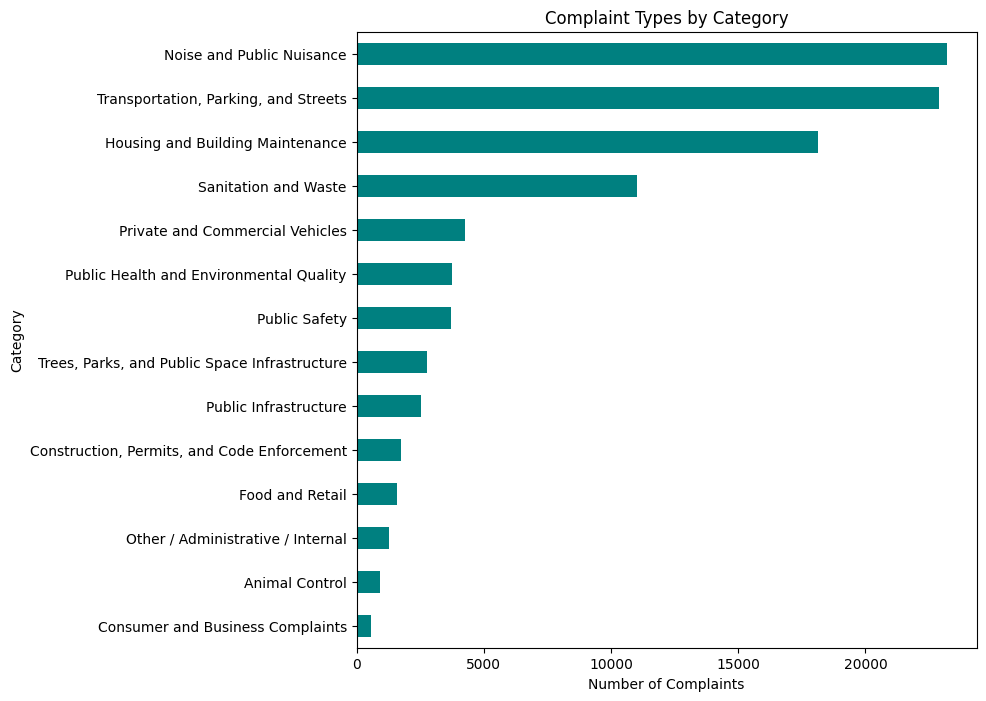

In [59]:
# plot complaint types by category
ax = (
    imputed_df["category"]
    .value_counts()
    .sort_values()
    .plot(kind="barh", figsize=(8, 8), color="teal")
)

ax.set_title("Complaint Types by Category")
ax.set_xlabel("Number of Complaints")
ax.set_ylabel("Category")

Text(0, 0.5, 'Borough')

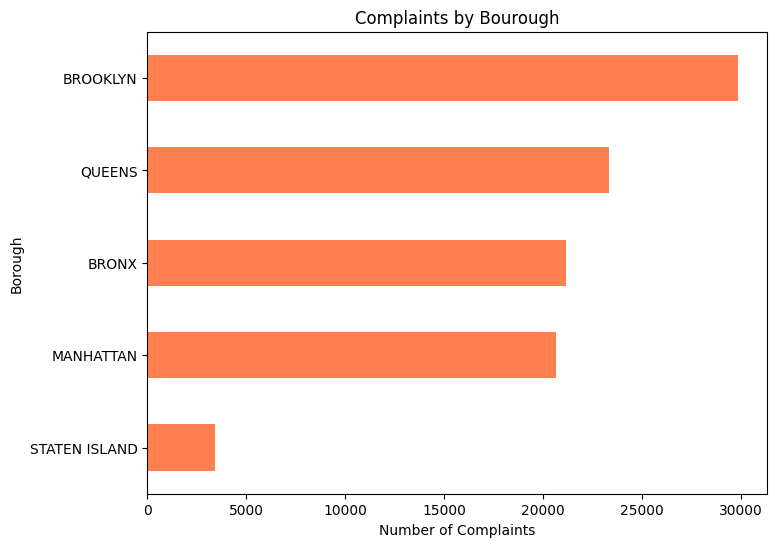

In [60]:
# plot complaint types by category
ax = (
    imputed_df["borough"]
    .value_counts()
    .sort_values()
    .plot(kind="barh", figsize=(8, 6), color="coral")
)

ax.set_title("Complaints by Bourough")
ax.set_xlabel("Number of Complaints")
ax.set_ylabel("Borough")

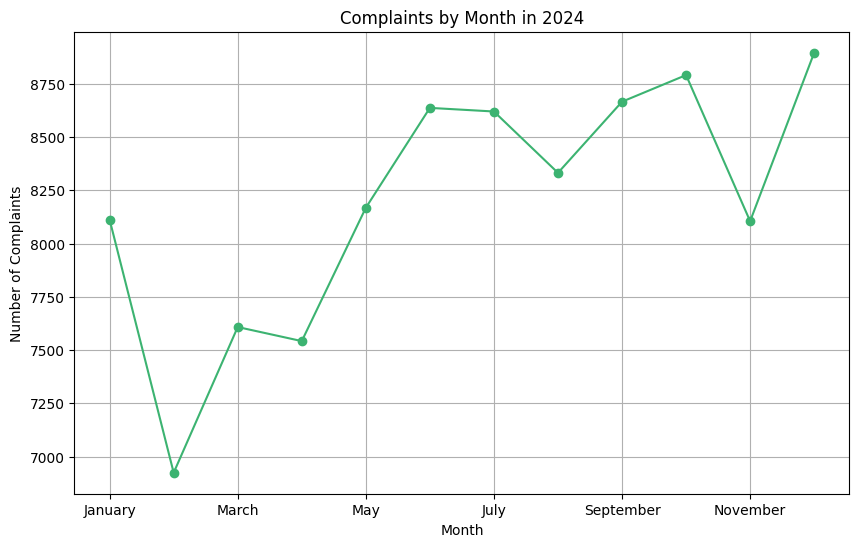

In [61]:
# convert created_date to datetime
imputed_df["created_date"] = pd.to_datetime(
    imputed_df["created_date"],
    errors="coerce"
)

# create month column
imputed_df["created_date_month"] = imputed_df["created_date"].dt.month

# count complaints by month in calendar order
monthly_counts = (
    imputed_df["created_date_month"]
    .value_counts()
    .sort_index()
)

# replace month numbers with month names
monthly_counts.index = monthly_counts.index.map(lambda x: calendar.month_name[int(x)])

# plot as line chart
ax = monthly_counts.plot(
    kind="line",
    figsize=(10, 6),
    marker="o",
    color="mediumseagreen"
)

ax.set_title("Complaints by Month in 2024")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Complaints")
ax.grid(True)

#### Average resolution time by category and agency

In [122]:
# ensure dates are datetime
imputed_df["created_date"] = pd.to_datetime(imputed_df["created_date"], errors="coerce")
imputed_df["closed_date"] = pd.to_datetime(imputed_df["closed_date"], errors="coerce")

# calculate resolution time in days
imputed_df["resolution_days"] = (
    imputed_df["closed_date"] - imputed_df["created_date"]
).dt.total_seconds() / 86400

# remove negative or missing resolution times if needed
resolution_df = imputed_df[
    imputed_df["resolution_days"].notna() &
    (imputed_df["resolution_days"] >= 0)
].copy()

# average resolution time by complaint category
category_resolution = (
    resolution_df
    .groupby("category")["resolution_days"]
    .mean()
    .sort_values(ascending=False)
)

# average resolution time by agency
agency_resolution = (
    resolution_df
    .groupby("agency")["resolution_days"]
    .mean()
    .sort_values(ascending=False)
)

In [123]:
category_resolution

category
Trees, Parks, and Public Space Infrastructure    132.181344
Construction, Permits, and Code Enforcement       87.327639
Food and Retail                                   61.054957
Public Infrastructure                             38.732058
Other / Administrative / Internal                 27.024180
Private and Commercial Vehicles                   19.572080
Housing and Building Maintenance                  17.167676
Consumer and Business Complaints                  16.780681
Public Health and Environmental Quality           10.928904
Sanitation and Waste                               8.889305
Public Safety                                      3.822945
Noise and Public Nuisance                          2.673174
Animal Control                                     1.881237
Transportation, Parking, and Streets               0.798399
Name: resolution_days, dtype: float64

In [124]:
agency_resolution

agency
DPR      115.770074
TLC       78.964400
DOB       67.198591
DOE       53.783753
EDC       52.882737
DOHMH     52.108275
DCWP      16.780681
HPD       14.199793
DOT       13.382440
OTI       10.733709
DSNY       5.460511
DEP        4.832895
DHS        4.522429
NYPD       0.119005
Name: resolution_days, dtype: float64

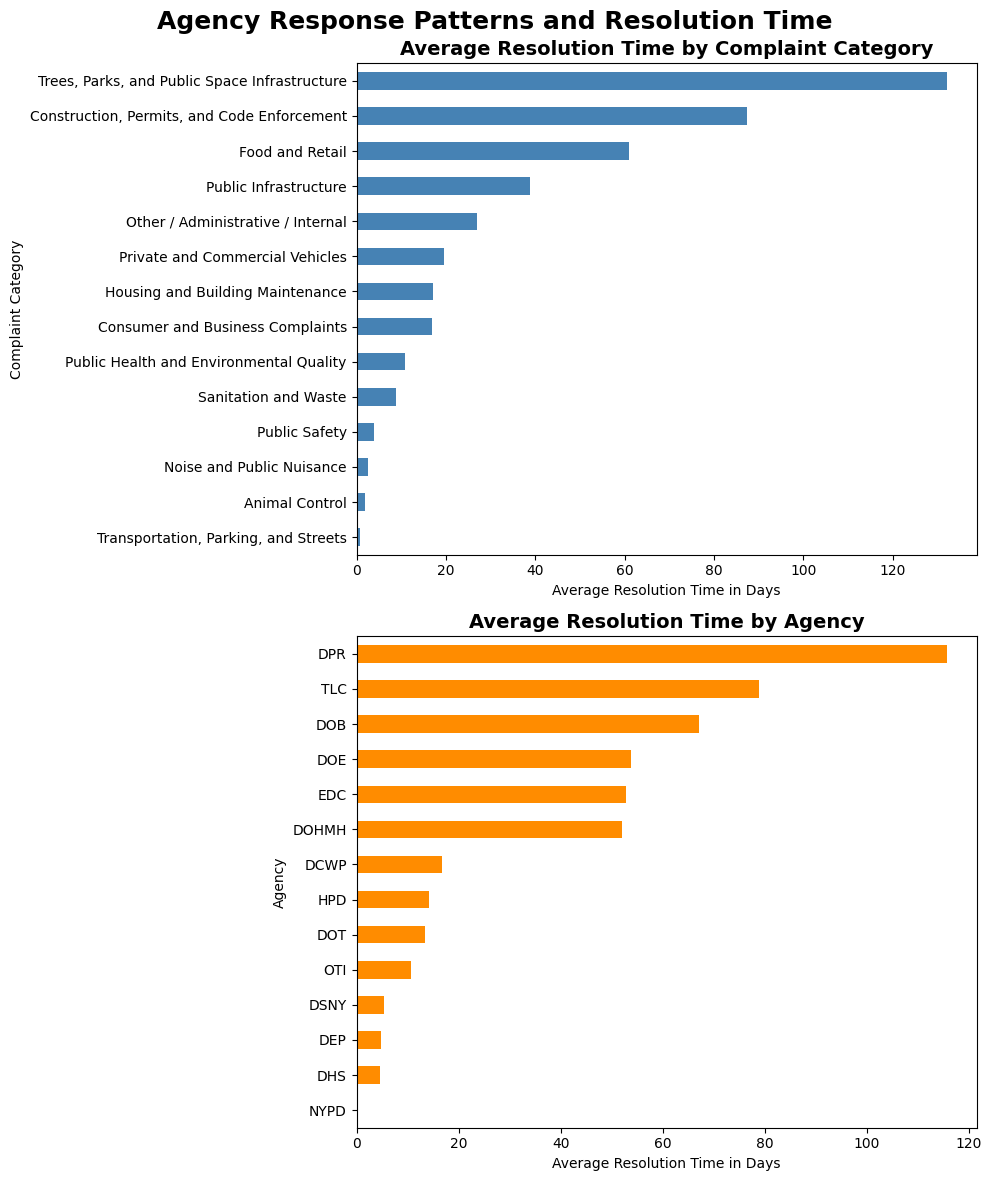

In [125]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Chart 1: category resolution time
category_resolution.plot(
    kind="barh",
    ax=axes[0],
    color="steelblue"
)

axes[0].invert_yaxis()
axes[0].set_title("Average Resolution Time by Complaint Category", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Average Resolution Time in Days")
axes[0].set_ylabel("Complaint Category")

# Chart 2: agency resolution time
agency_resolution.plot(
    kind="barh",
    ax=axes[1],
    color="darkorange"
)

axes[1].invert_yaxis()
axes[1].set_title("Average Resolution Time by Agency", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Average Resolution Time in Days")
axes[1].set_ylabel("Agency")

fig.suptitle(
    "Agency Response Patterns and Resolution Time",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

plt.tight_layout()
plt.show()

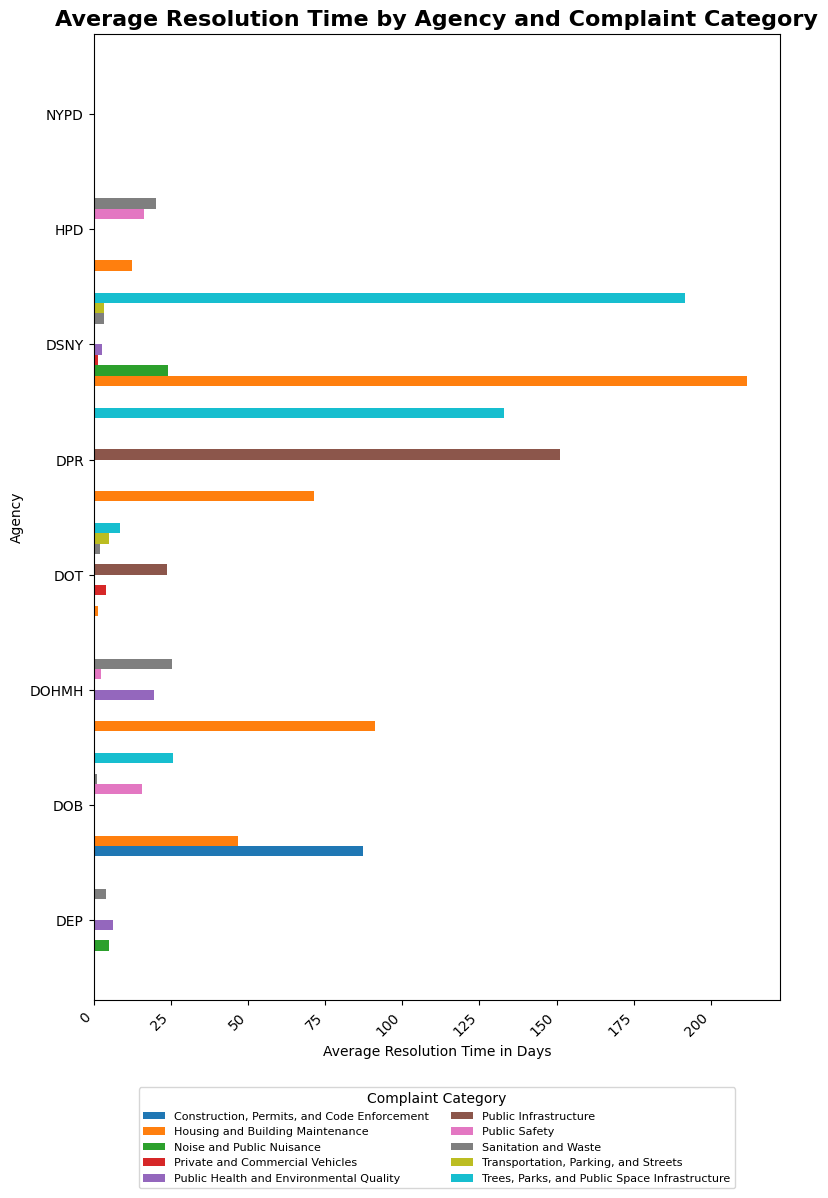

In [132]:
top_agencies = resolution_df["agency"].value_counts().head(8).index
top_categories = resolution_df["category"].value_counts().head(10).index

agency_category_resolution = (
    resolution_df[
        resolution_df["agency"].isin(top_agencies) &
        resolution_df["category"].isin(top_categories)
    ]
    .groupby(["agency", "category"])["resolution_days"]
    .mean()
    .unstack(fill_value=0)
)

ax = agency_category_resolution.plot(
    kind="barh",
    figsize=(8, 12),
    width=0.9
)

ax.set_title(
    "Average Resolution Time by Agency and Complaint Category",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Average Resolution Time in Days")
ax.set_ylabel("Agency")

ax.legend(
    title="Complaint Category",
    bbox_to_anchor=(0.5, -0.2),
    loc="lower center",
    ncol=2,
    fontsize=8
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
### Geocode Heat Map

In [62]:
# convert ZIP code to string
imputed_df["incident_zip"] = imputed_df["incident_zip"].astype("Int64").astype(str)

# remove missing/invalid ZIPs if needed
imputed_df = imputed_df[imputed_df["incident_zip"].notna()]
imputed_df = imputed_df[imputed_df["borough"].notna()]

zip_counts = (
    imputed_df.groupby(["borough", "incident_zip"])
    .size()
    .reset_index(name="complaint_count")
)

zip_counts.head()

,borough,incident_zip,complaint_count
0,BRONX,10037,1
1,BRONX,10451,724
2,BRONX,10452,1310
3,BRONX,10453,1156
4,BRONX,10454,492


In [63]:
# API endpoint for NYC ZIP code boundaries in GeoJSON format
url = "https://data.cityofnewyork.us/api/geospatial/pri4-ifjk?method=export&format=GeoJSON"

zip_shapes = gpd.read_file(url)
zip_shapes.head()

,modzcta,label,zcta,pop_est,geometry
0,10001,"10001, 10118","10001, 10119, 10199",23072,"MULTIPOLYGON (((-73.98774 40.74407, -73.98819 ..."
1,10002,10002,10002,74993,"MULTIPOLYGON (((-73.9975 40.71407, -73.99709 4..."
2,10003,10003,10003,54682,"MULTIPOLYGON (((-73.98864 40.72293, -73.98876 ..."
3,10026,10026,10026,39363,"MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ..."
4,10004,10004,10004,3028,"MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ..."


In [64]:
# merge ZIP code data with complaint counts
zip_shapes["incident_zip"] = zip_shapes["modzcta"].astype(str)

# ensure the population column is numeric
zip_shapes["pop_est"] = pd.to_numeric(zip_shapes["pop_est"], errors="coerce")

map_df = zip_shapes.merge(
    zip_counts,
    on="incident_zip",
    how="left"
)

In [65]:
# population and complaint count by borough
borough_summary = (
    map_df
    .groupby("borough")
    .agg(
        pop_est=("pop_est", "sum"),
        complaint_count=("complaint_count", "sum")
    )
    .reset_index()
)

# calculate complaints per person
borough_summary["complaints_per_person"] = (
    borough_summary["complaint_count"] / borough_summary["pop_est"]
)

# calculate complaints per 100,000 residents
borough_summary["complaints_per_100k"] = (
    borough_summary["complaint_count"] / borough_summary["pop_est"] * 100000
)

borough_summary

,borough,pop_est,complaint_count,complaints_per_person,complaints_per_100k
0,BRONX,1462594,21164.0,0.014470,1447.018106
1,BROOKLYN,2707464,29412.0,0.010863,1086.330234
2,MANHATTAN,1693131,20467.0,0.012088,1208.825543
3,QUEENS,2354872,23173.0,0.009840,984.044993
4,STATEN ISLAND,474101,3440.0,0.007256,725.583789


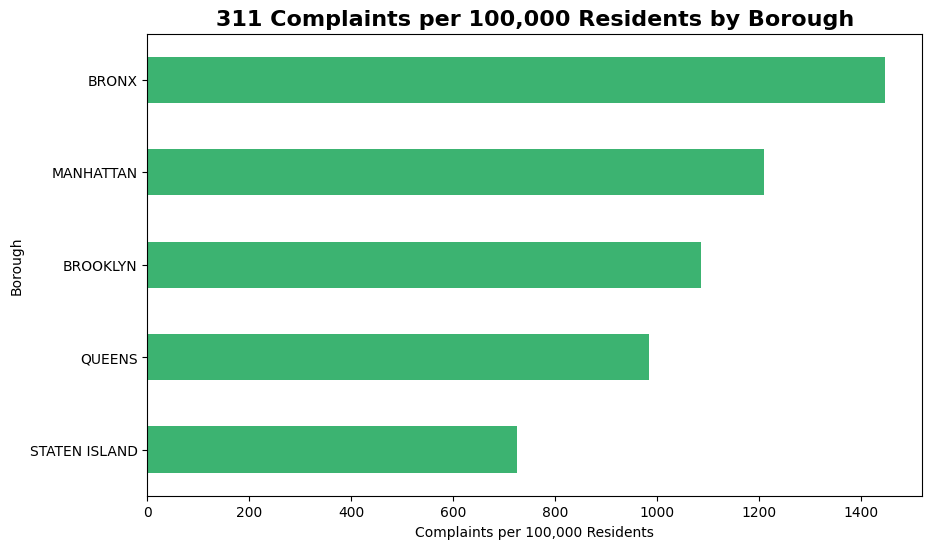

In [66]:
ax = borough_summary.sort_values("complaints_per_100k", ascending=False).plot(
    x="borough",
    y="complaints_per_100k",
    kind="barh",
    figsize=(10, 6),
    color="mediumseagreen",
    legend=False
)

ax.set_title(
    "311 Complaints per 100,000 Residents by Borough",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Complaints per 100,000 Residents")
ax.set_ylabel("Borough")

ax.invert_yaxis()

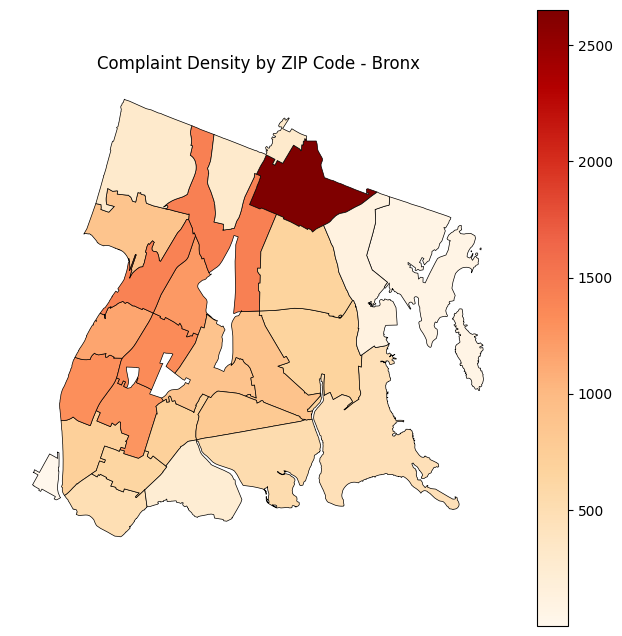

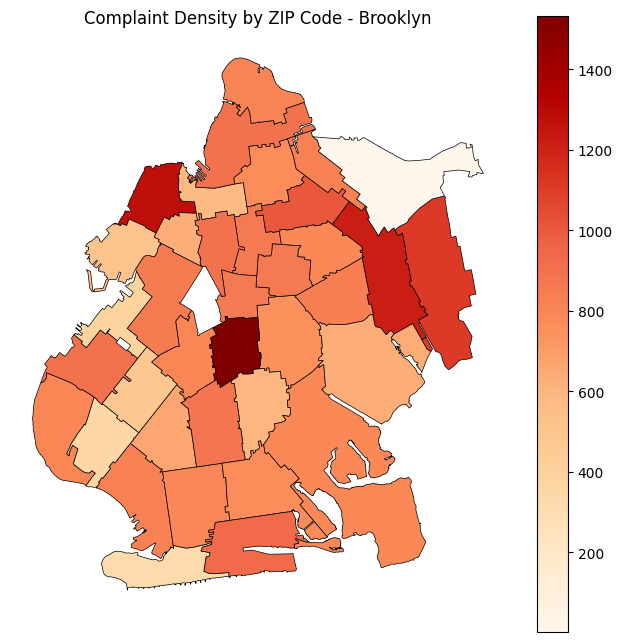

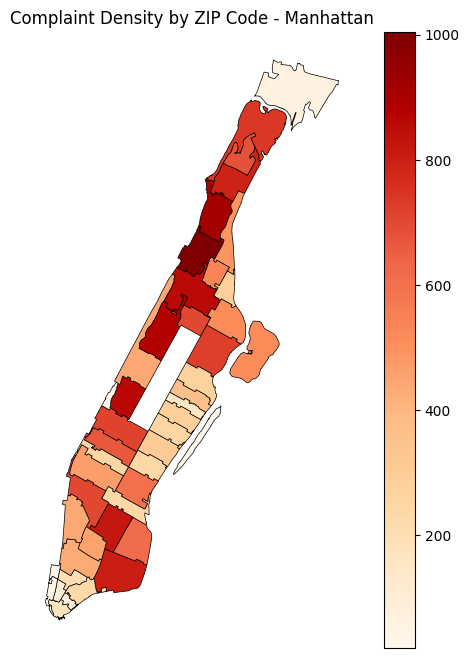

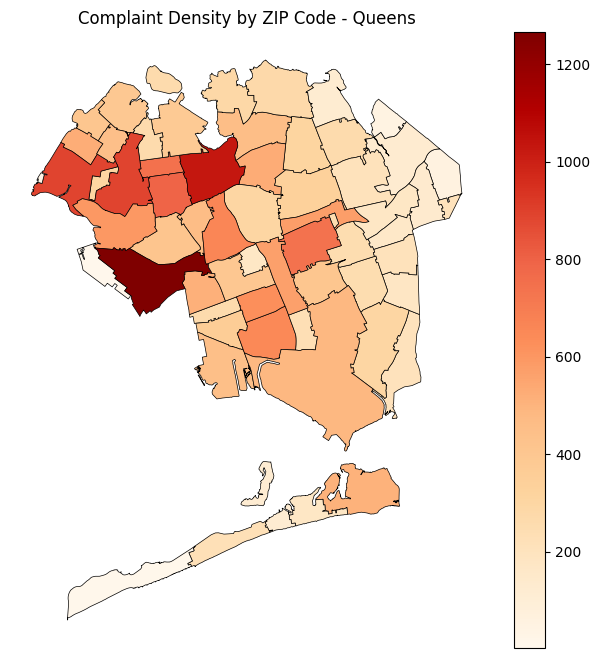

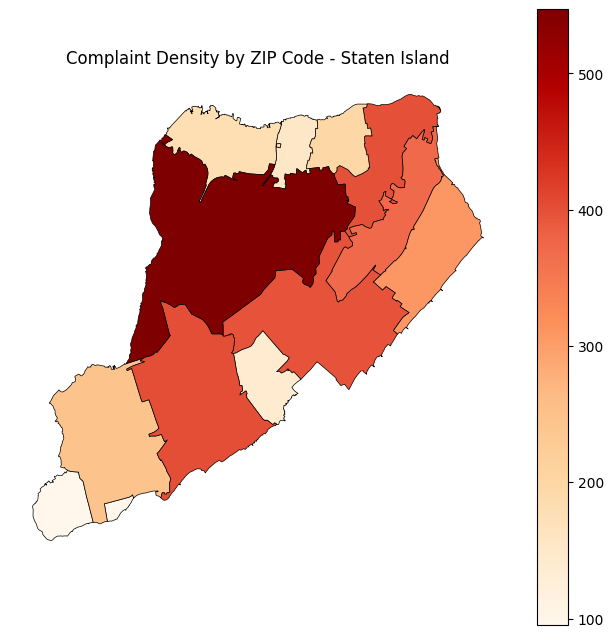

In [67]:
boroughs = sorted(map_df["borough"].dropna().unique())

# plot choropleth maps for each borough
for b in boroughs:
    borough_map = map_df[map_df["borough"] == b]

    fig, ax = plt.subplots(figsize=(8, 8))
    borough_map.plot(
        column="complaint_count",
        cmap="OrRd",
        linewidth=0.5,
        edgecolor="black",
        legend=True,
        ax=ax
    )

    ax.set_title(f"Complaint Density by ZIP Code - {b.title()}")
    ax.axis("off")
    plt.show()

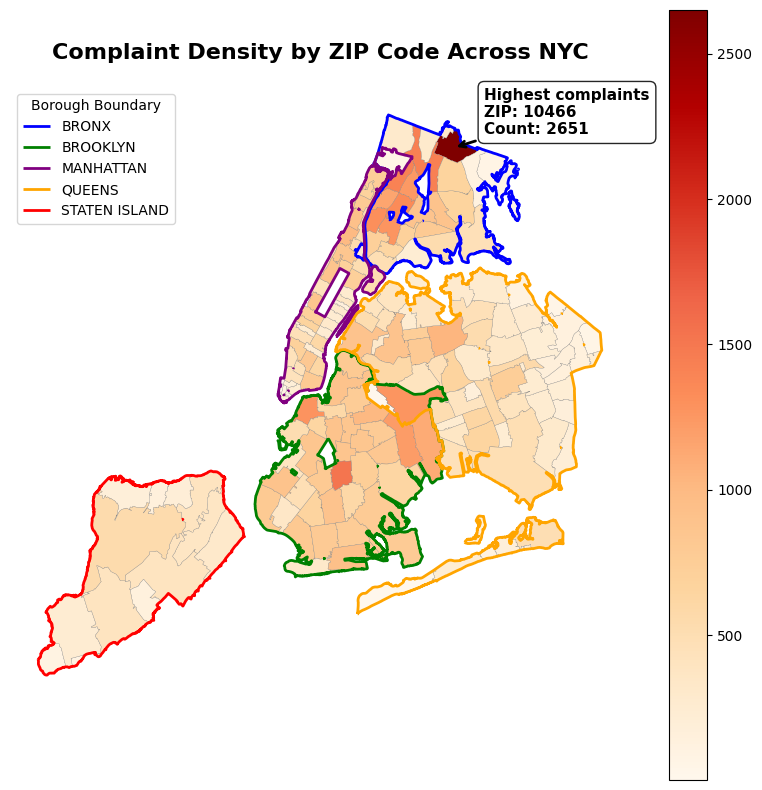

In [68]:
fig, ax = plt.subplots(figsize=(10, 10))

# Base choropleth: complaint density
map_df.plot(
    column="complaint_count",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    ax=ax
)

# Overlay each borough boundary in a different color
borough_colors = {
    "BRONX": "blue",
    "BROOKLYN": "green",
    "MANHATTAN": "purple",
    "QUEENS": "orange",
    "STATEN ISLAND": "red"
}

for borough, color in borough_colors.items():
    borough_boundary = map_df[map_df["borough"] == borough].dissolve()
    borough_boundary.boundary.plot(ax=ax, color=color, linewidth=2, label=borough)

ax.set_title("Complaint Density by ZIP Code Across NYC", 
             fontsize=16,
             fontweight="bold",
             pad=20)
ax.axis("off")
ax.legend(title="Borough Boundary", loc="upper left")

# Find ZIP with the highest complaint count
top_zip = map_df.loc[map_df["complaint_count"].idxmax()]
top_point = top_zip.geometry.centroid

# Annotate the ZIP code with the highest complaint count
ax.annotate(
    f"Highest complaints\nZIP: {top_zip['modzcta']}\nCount: {int(top_zip['complaint_count'])}",
    xy=(top_point.x, top_point.y), # arrow points here
    xytext=(top_point.x + 0.03, top_point.y + 0.01), # text box location
    arrowprops=dict(arrowstyle="->", linewidth=2, color="black"),
    fontsize=11,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="black",
        alpha=0.85
    )
)

plt.show()

In [133]:
# make sure ZIP codes are strings
imputed_df["incident_zip"] = imputed_df["incident_zip"].astype(str).str.replace(".0", "", regex=False)

# filter to ZIP code 10466
zip_10466_df = imputed_df[imputed_df["incident_zip"] == "10466"]

# count complaint types in 10466
complaints_10466 = (
    zip_10466_df["complaint_type"]
    .value_counts()
    .reset_index()
)

complaints_10466.columns = ["complaint_type", "complaint_count"]

complaints_10466.head(20)

,complaint_type,complaint_count
0,Noise - Residential,1922
1,Illegal Parking,121
2,Heat/Hot Water,118
3,Blocked Driveway,53
4,Unsanitary Condition,39
5,Paint/Plaster,29
6,Plumbing,23
7,Water Leak,21
8,Water System,19
9,Abandoned Vehicle,18


Text(0, 0.5, 'Complaint Type')

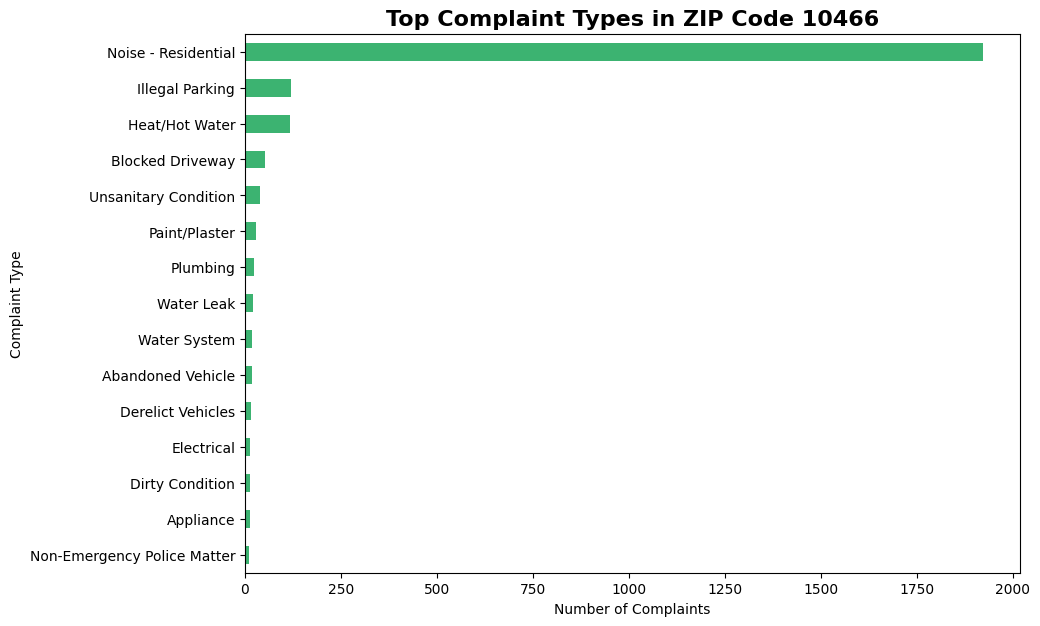

In [134]:
ax = (
    complaints_10466
    .head(15)
    .sort_values("complaint_count")
    .plot(
        x="complaint_type",
        y="complaint_count",
        kind="barh",
        figsize=(10, 7),
        color="mediumseagreen",
        legend=False
    )
)

ax.set_title("Top Complaint Types in ZIP Code 10466", fontsize=16, fontweight="bold")
ax.set_xlabel("Number of Complaints")
ax.set_ylabel("Complaint Type")

#### Time Series Trends

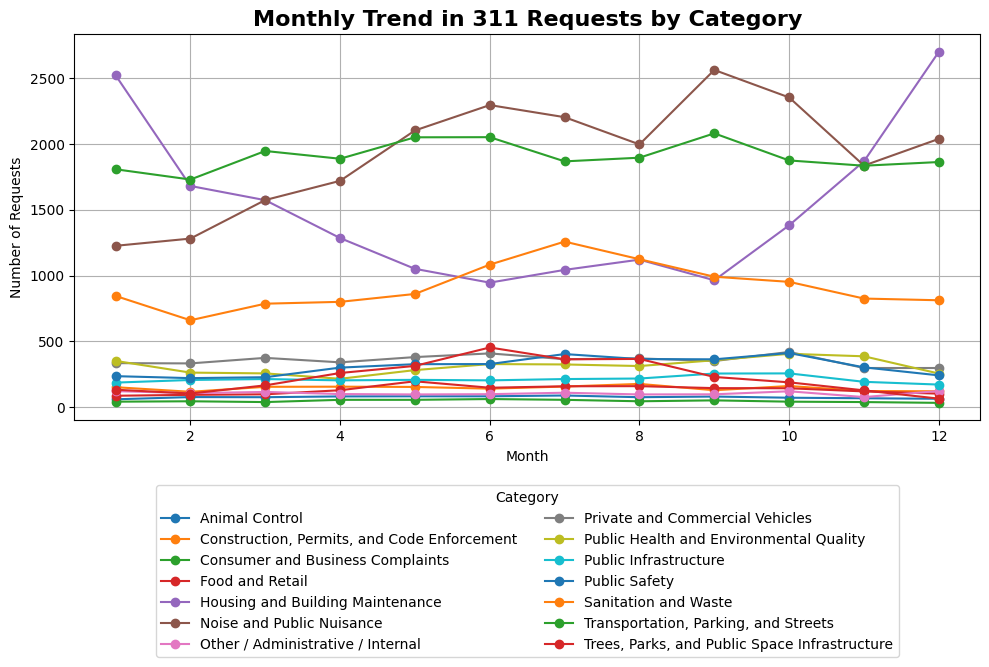

In [69]:
monthly_category = (
    imputed_df
    .groupby(["created_date_month", "category"])
    .size()
    .unstack(fill_value=0)
)

ax = monthly_category.plot(
    kind="line",
    figsize=(10, 7),
    marker="o"
)

ax.set_title("Monthly Trend in 311 Requests by Category", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Requests")
ax.grid(True)

# place legend below the plot, centered, with 2 columns
ax.legend(title="Category", 
          bbox_to_anchor=(0.5, -0.15), 
          loc="upper center", 
          ncol=2)

plt.tight_layout()
plt.show()

---
### Step 6: Dashboard Mockup

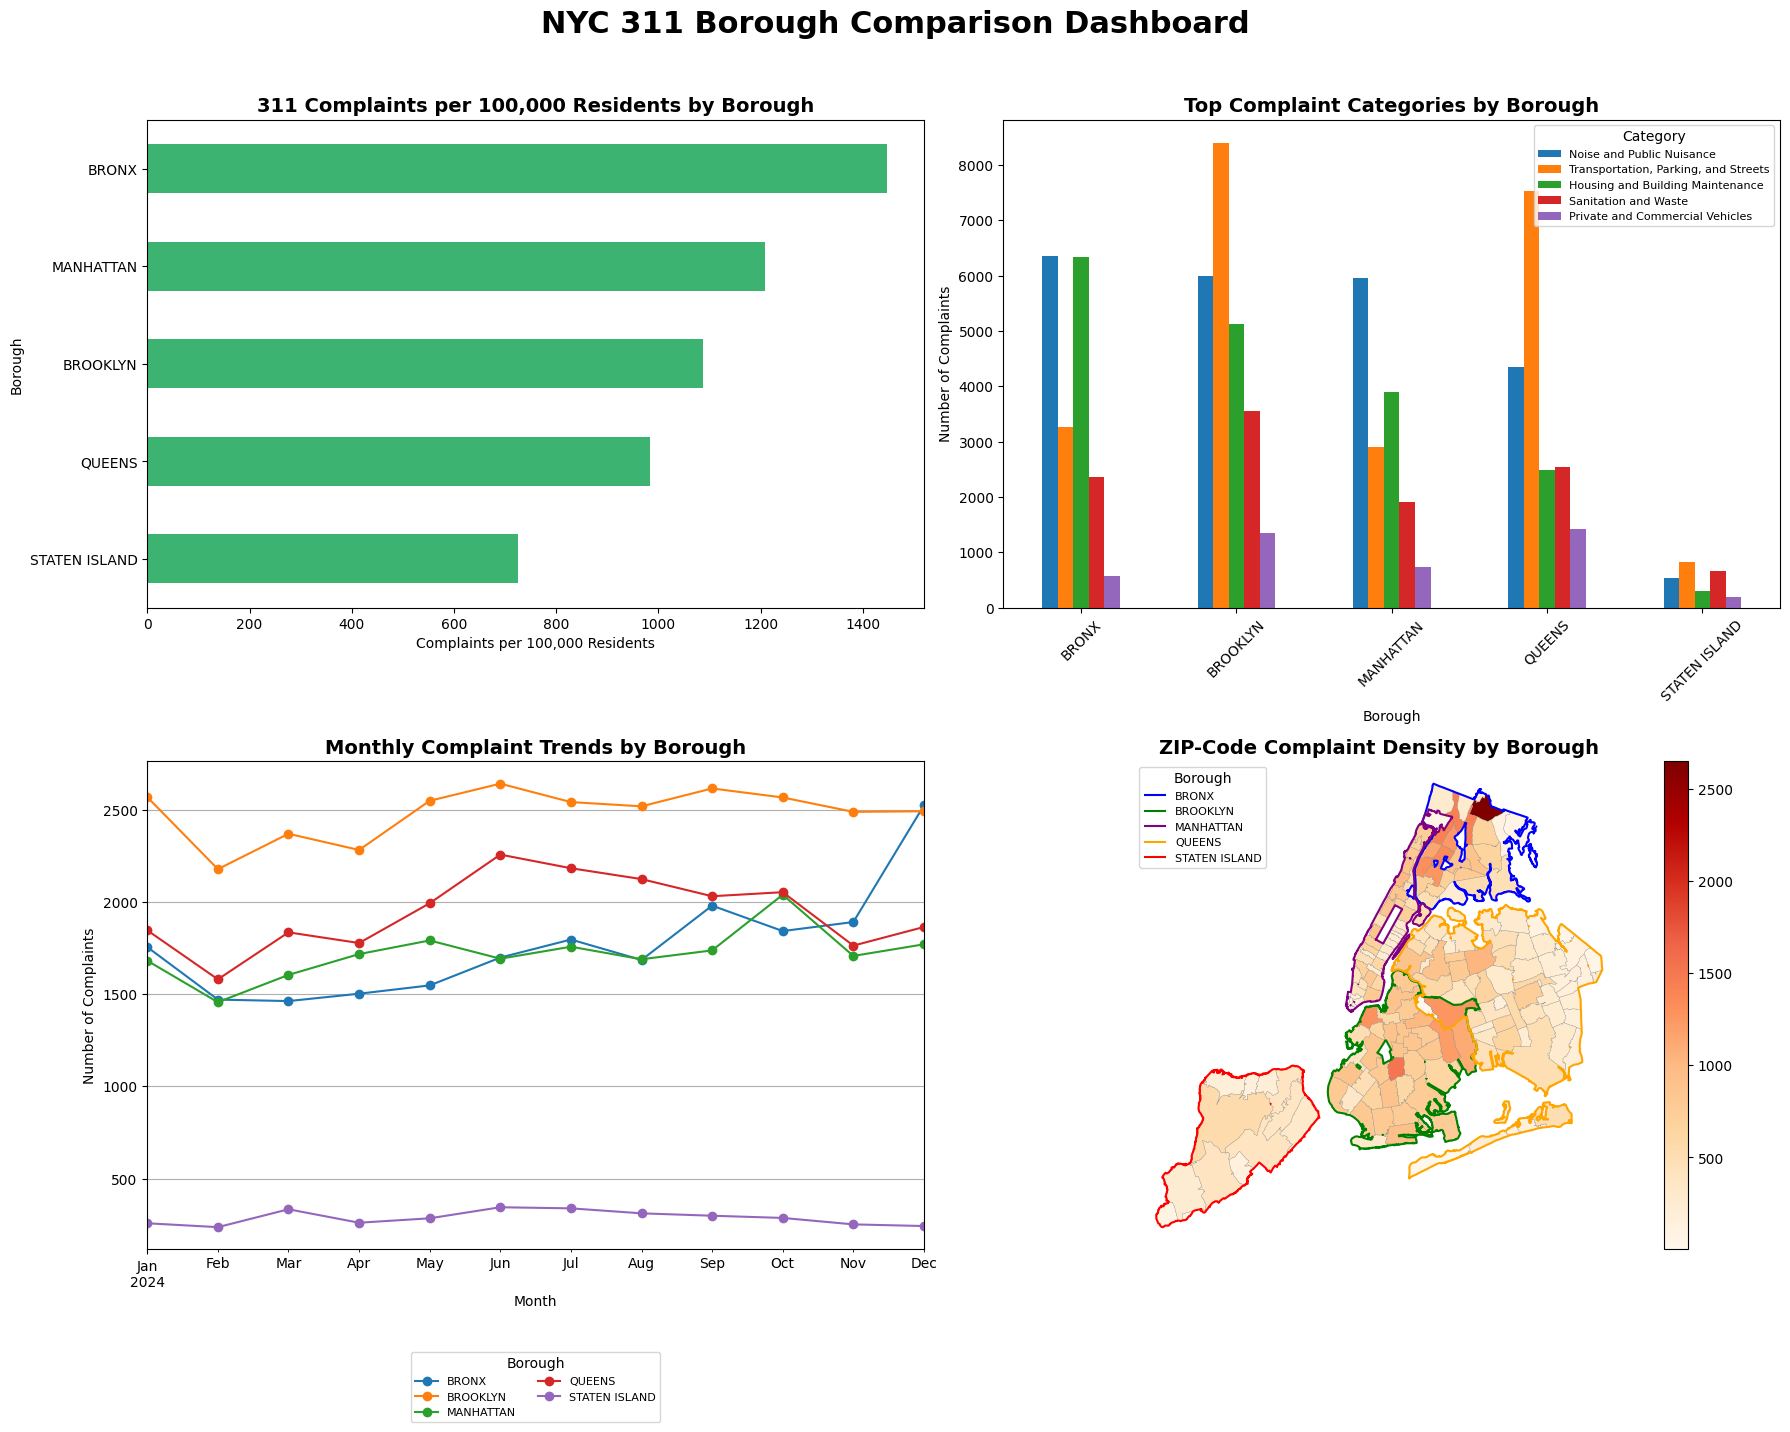

In [70]:
# ensure created_date is datetime
imputed_df["created_date"] = pd.to_datetime(imputed_df["created_date"], errors="coerce")
imputed_df["month"] = imputed_df["created_date"].dt.to_period("M").dt.to_timestamp()

# make sure borough values match
imputed_df["borough"] = imputed_df["borough"].str.upper()
map_df["borough"] = map_df["borough"].str.upper()

# 1. Complaints per 100k residents by borough
borough_summary = (
    map_df
    .groupby("borough")
    .agg(
        pop_est=("pop_est", "sum"),
        complaint_count=("complaint_count", "sum")
    )
    .reset_index()
)

borough_summary["complaints_per_100k"] = (
    borough_summary["complaint_count"] / borough_summary["pop_est"] * 100000
)

borough_summary_sorted = borough_summary.sort_values(
    "complaints_per_100k",
    ascending=False
)

# 2. Category counts by borough
borough_category = (
    imputed_df
    .groupby(["borough", "category"])
    .size()
    .unstack(fill_value=0)
)

# keep only top categories so the chart is readable
top_categories = imputed_df["category"].value_counts().head(5).index
borough_category_top = borough_category[top_categories]

# 3. Monthly trends by borough
monthly_borough = (
    imputed_df
    .groupby(["month", "borough"])
    .size()
    .unstack(fill_value=0)
)

# create dashboard layout
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Chart 1: complaints per 100k residents by borough
borough_summary_sorted.plot(
    x="borough",
    y="complaints_per_100k",
    kind="barh",
    ax=axes[0, 0],
    color="mediumseagreen",
    legend=False
)

axes[0, 0].invert_yaxis()
axes[0, 0].set_title("311 Complaints per 100,000 Residents by Borough", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Complaints per 100,000 Residents")
axes[0, 0].set_ylabel("Borough")

# Chart 2: top complaint categories by borough
borough_category_top.plot(
    kind="bar",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Top Complaint Categories by Borough", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Borough")
axes[0, 1].set_ylabel("Number of Complaints")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].legend(
    title="Category",
    loc="upper right",
    fontsize=8
)

# Chart 3: monthly trends by borough
monthly_borough.plot(
    kind="line",
    ax=axes[1, 0],
    marker="o"
)

axes[1, 0].set_title("Monthly Complaint Trends by Borough", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Number of Complaints")
axes[1, 0].grid(True)
axes[1, 0].legend(
    title="Borough",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=2,
    fontsize=8
)

# Chart 4: ZIP-code complaint density map
map_df.plot(
    column="complaint_count",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    ax=axes[1, 1]
)

borough_colors = {
    "BRONX": "blue",
    "BROOKLYN": "green",
    "MANHATTAN": "purple",
    "QUEENS": "orange",
    "STATEN ISLAND": "red"
}

for borough, color in borough_colors.items():
    borough_boundary = map_df[map_df["borough"] == borough].dissolve()
    borough_boundary.boundary.plot(
        ax=axes[1, 1],
        color=color,
        linewidth=1.5,
        label=borough
    )

axes[1, 1].set_title("ZIP-Code Complaint Density by Borough", fontsize=14, fontweight="bold")
axes[1, 1].axis("off")
axes[1, 1].legend(
    title="Borough",
    loc="upper left",
    fontsize=8
)

# dashboard title
fig.suptitle(
    "NYC 311 Borough Comparison Dashboard",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()